# Member 5 — Feature Engineering

**Technique:** Engineer handcrafted visual features from each leaf image (RGB + HSV histograms and channel statistics).

## Why this dataset needs it
Raw pixels are high-dimensional and noisy. Compact color descriptors summarise **health-related appearance** (greenness, discoloration) in a form classical models can learn from.


In [5]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


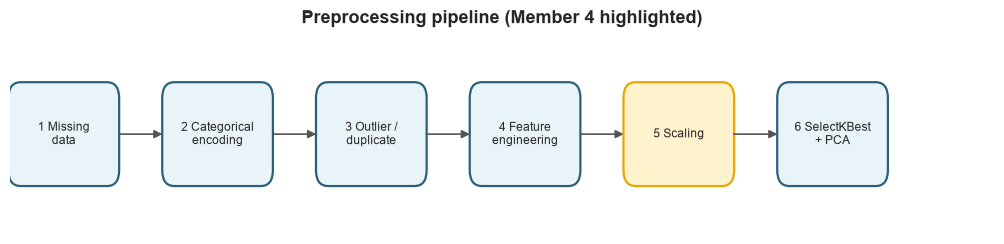

In [6]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 4 highlighted)",
    highlight=4,
)
fig.savefig(VIZ / "m4_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
from skimage.color import rgb2hsv
from PIL import Image

meta_path = OUT / "m3_cleaned_no_outliers.csv"
meta = pd.read_csv(meta_path) if meta_path.exists() else audit_images(RAW)[0]
sample = meta  # Process all images in the dataset

# Build a readable feature table (subset of engineered columns)
rows = []
for row in sample.to_dict("records"):
    im = read_rgb(RAW / row["path"])
    rgb = np.asarray(im.resize((64, 64), Image.Resampling.BILINEAR), dtype=np.float32) / 255.0
    hsv = rgb2hsv(rgb)
    rows.append({
        "path": row["path"],
        "label": row["label"],
        "rgb_r_mean": float(rgb[:, :, 0].mean()),
        "rgb_g_mean": float(rgb[:, :, 1].mean()),
        "rgb_b_mean": float(rgb[:, :, 2].mean()),
        "hsv_h_mean": float(hsv[:, :, 0].mean()),
        "hsv_s_mean": float(hsv[:, :, 1].mean()),
        "hsv_v_mean": float(hsv[:, :, 2].mean()),
        "rgb_g_std": float(rgb[:, :, 1].std()),
        "hsv_s_std": float(hsv[:, :, 1].std()),
    })

feat_df = pd.DataFrame(rows)
display(feat_df.head())
feat_df.to_csv(OUT / "m5_engineered_color_features.csv", index=False)
print("Engineered feature rows:", len(feat_df))


,path,label,rgb_r_mean,rgb_g_mean,rgb_b_mean,hsv_h_mean,hsv_s_mean,hsv_v_mean,rgb_g_std,hsv_s_std
0,Nagpur_Region_Basil_Plant_Healthy/IMG-20191027...,Healthy,0.781481,0.809302,0.694012,0.098761,0.188327,0.814033,0.237875,0.225490
1,Nagpur_Region_Basil_Plant_Healthy/IMG-20191027...,Healthy,0.772407,0.801038,0.602887,0.095292,0.335962,0.805543,0.293879,0.366227
2,Nagpur_Region_Basil_Plant_Healthy/IMG-20191027...,Healthy,0.800579,0.829821,0.724459,0.101093,0.154441,0.832599,0.205304,0.212791
3,Nagpur_Region_Basil_Plant_Healthy/IMG-20191027...,Healthy,0.744323,0.787479,0.681556,0.127688,0.194810,0.790346,0.284497,0.244524
4,Nagpur_Region_Basil_Plant_Healthy/IMG-20191027...,Healthy,0.760321,0.802029,0.713243,0.133250,0.163436,0.807384,0.243209,0.199625


Engineered feature rows: 1076


## EDA visualizations — correlation, greenness & RGB channel comparisons


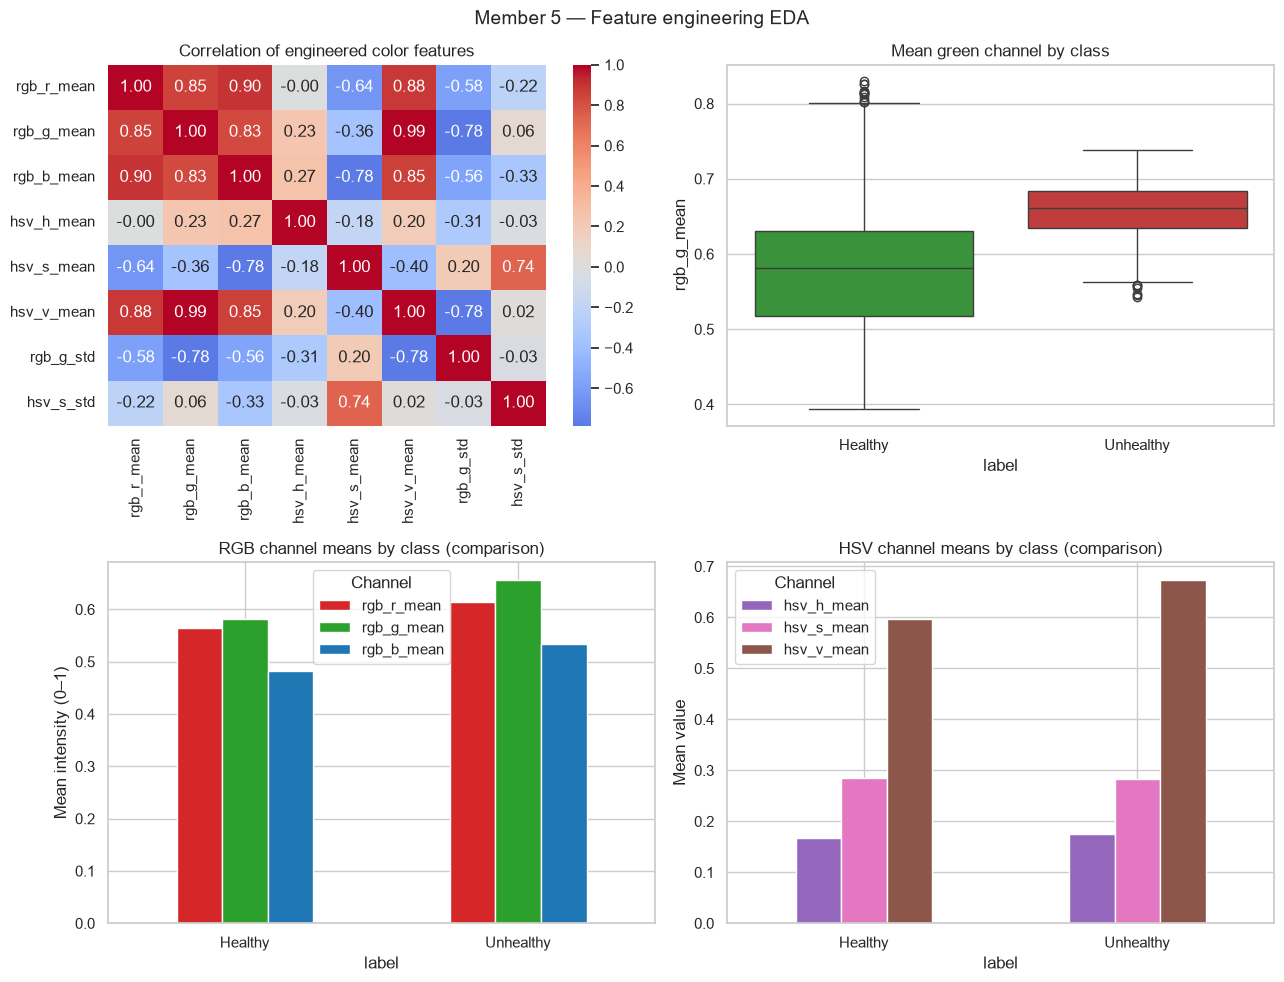

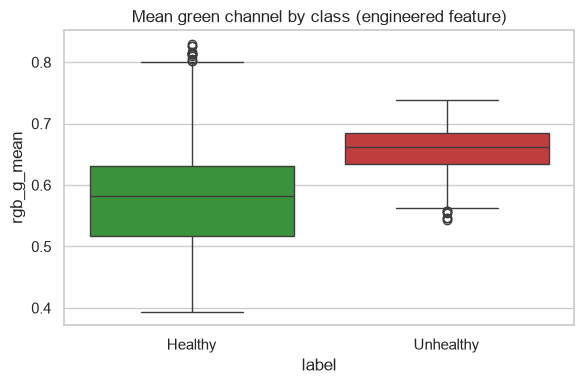

Interpretation: correlation shows redundancy among features; green-channel stats often separate healthy vs unhealthy leaves.


In [8]:
num_cols = [c for c in feat_df.columns if c not in {"path", "label"}]
corr = feat_df[num_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0, 0])
axes[0, 0].set_title("Correlation of engineered color features")

sns.boxplot(data=feat_df, x="label", y="rgb_g_mean", hue="label", order=CLASSES, palette=["#2ca02c", "#d62728"], ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Mean green channel by class")

# Grouped bar: mean RGB channels by class
channel_means = feat_df.groupby("label")[["rgb_r_mean", "rgb_g_mean", "rgb_b_mean"]].mean().reindex(CLASSES)
channel_means.plot(kind="bar", ax=axes[1, 0], color=["#d62728", "#2ca02c", "#1f77b4"], rot=0)
axes[1, 0].set_title("RGB channel means by class (comparison)")
axes[1, 0].set_ylabel("Mean intensity (0–1)")
axes[1, 0].legend(title="Channel")

# HSV mean comparison by class
hsv_means = feat_df.groupby("label")[["hsv_h_mean", "hsv_s_mean", "hsv_v_mean"]].mean().reindex(CLASSES)
hsv_means.plot(kind="bar", ax=axes[1, 1], color=["#9467bd", "#e377c2", "#8c564b"], rot=0)
axes[1, 1].set_title("HSV channel means by class (comparison)")
axes[1, 1].set_ylabel("Mean value")
axes[1, 1].legend(title="Channel")

fig.suptitle("Member 5 — Feature engineering EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m5_feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=feat_df, x="label", y="rgb_g_mean", hue="label", order=CLASSES, palette=["#2ca02c", "#d62728"], ax=ax, legend=False)
ax.set_title("Mean green channel by class (engineered feature)")
fig.tight_layout()
fig.savefig(VIZ / "m5_greenness_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: correlation shows redundancy among features; green-channel stats often separate healthy vs unhealthy leaves.")
